In [91]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [92]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [93]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [94]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [95]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (106947980145)>


Running FoS = 1.00
Running FoS = 1.05
Running FoS = 1.10
Running FoS = 1.15
Running FoS = 1.20
Running FoS = 1.25
Running FoS = 1.30
Running FoS = 1.35
Running FoS = 1.40
Running FoS = 1.45


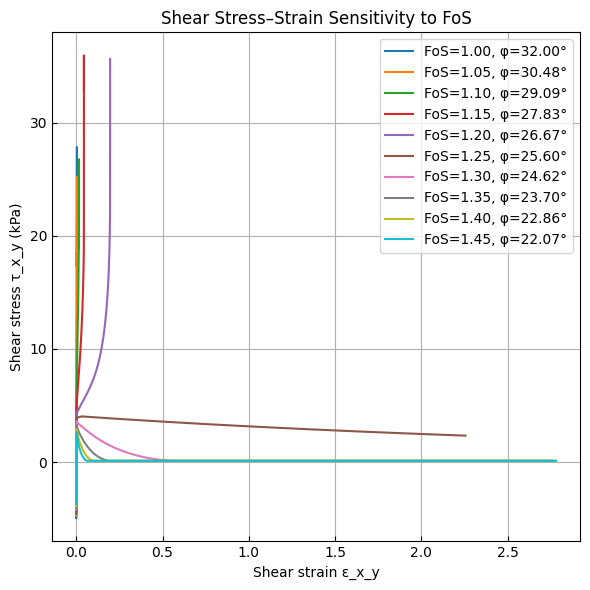

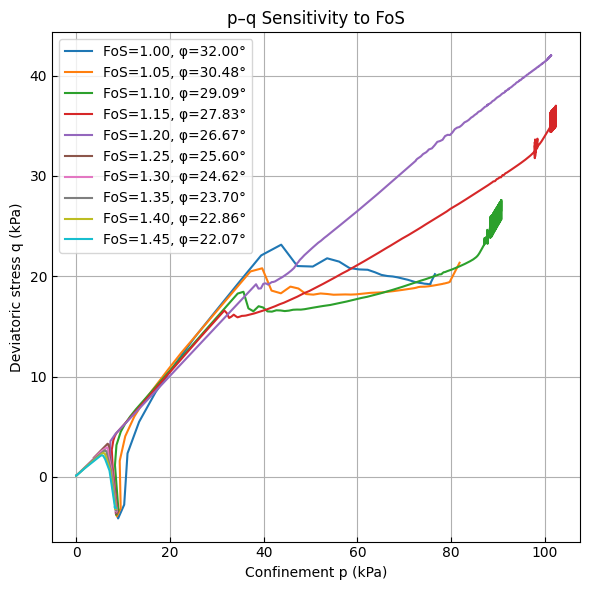

In [ ]:
import openseespy.opensees as ops
import numpy as np
import matplotlib.pyplot as plt
import os

def compute_pq(stress):
    po = (stress[:, 1] + stress[:, 2] + stress[:, 3]) / 3
    qo = np.sign(stress[:, 4]) * (1 / 3.0) * np.sqrt(
        (stress[:, 1] - stress[:, 2]) ** 2 +
        (stress[:, 2] - stress[:, 3]) ** 2 +
        (stress[:, 1] - stress[:, 3]) ** 2 +
        6.0 * stress[:, 4] ** 2
    )
    return po, qo

def run_analysis(fos, base_fangle=32.0):
    ops.wipe()

    matOpt = 1
    fmass = 1.0
    smass = 2.0
    G = 9.0e4
    B = 2.2e5
    bulk = 2.2e6
    vperm = 5.e-6 / (9.81 * fmass)
    hperm = vperm

    loadBias = 0.0
    deltaT = 0.01
    gamma = 0.6
    numSteps = 1000
    massProportionalDamping = 0.0
    InitStiffnessProportionalDamping = 0.002

    gravY = -9.81
    gravX = -gravY * loadBias
    fangle = base_fangle / fos

    # Fluid phase
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.node(1, 0, 0)
    ops.node(2, 2.5, 0)
    ops.node(3, 2.5, 2)
    ops.node(4, 0, 2)
    ops.fix(1, 1, 1, 0)
    ops.fix(2, 1, 1, 0)
    ops.fix(3, 0, 0, 1)
    ops.fix(4, 0, 0, 1)
    ops.equalDOF(3, 4, 1, 2)

    # Solid phase
    ops.model('basic', '-ndm', 2, '-ndf', 2)
    ops.node(5, 1.25, 0.)
    ops.node(6, 2.5, 1)
    ops.node(7, 1.25, 2)
    ops.node(8, 0, 1)
    ops.node(9, 1.25, 1)
    ops.fix(5, 1, 1)
    ops.equalDOF(3, 7, 1, 2)
    ops.equalDOF(6, 8, 1, 2)
    ops.equalDOF(6, 9, 1, 2)

    if matOpt == 1:
        ops.nDMaterial("PressureDependMultiYield02", 1, 2, 1.8, G, B, fangle, 0.1, 80, 0.5,
                       26.0, 0.067, 0.23, 0.06, 0.27)
    else:
        ops.nDMaterial("PressureIndependMultiYield", 2, 2, 1.8, 4.e4, 2.e5, 40, 0.1)

    ops.element("9_4_QuadUP", 1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1.0, 1, bulk, fmass, hperm, vperm, gravX, gravY)

    ops.updateMaterialStage('-material', 1, '-stage', 0)
    ops.numberer("RCM")
    ops.system("ProfileSPD")
    ops.test("NormDispIncr", 1.0e-8, 30, 0)
    ops.algorithm("KrylovNewton")
    ops.constraints("Penalty", 1.e18, 1.e18)
    ops.integrator("Newmark", 1.5, (1.5 + 0.5) ** 2 / 4)
    ops.analysis("Transient")
    ops.analyze(10, 5e3)

    ops.updateMaterialStage('-material', 1, '-stage', 1)

    # Prepare dynamic analysis
    ops.wipeAnalysis()
    ops.timeSeries('Linear', 1)
    ops.pattern('Plain', 1, 1)
    ops.load(3, 0.001, 0.0, 0.0)
    ops.recorder('Element', '-ele', 1, '-time', '-file', 'tstress1', '-dT', deltaT, 'material', 1, 'stress')
    ops.recorder('Element', '-ele', 1, '-time', '-file', 'tstrain1', '-dT', deltaT, 'material', 1, 'strain')

    ops.constraints("Penalty", 1.e18, 1.e18)
    ops.test("NormDispIncr", 1.e-4, 25, 0)
    ops.numberer("RCM")
    ops.algorithm("KrylovNewton")
    ops.system("ProfileSPD")
    ops.integrator("Newmark", gamma, (gamma + 0.5) ** 2 / 4)
    ops.rayleigh(massProportionalDamping, 0.0, InitStiffnessProportionalDamping, 0.0)
    ops.analysis("VariableTransient")

    steps_run = 0
    for step in range(numSteps):
        ok = ops.analyze(1, deltaT)
        if ok != 0:
            break
        steps_run += 1

    ops.wipe()

    if not os.path.exists('tstress1') or os.path.getsize('tstress1') == 0:
        return None

    s1 = np.loadtxt('tstress1')
    e1 = np.loadtxt('tstrain1')
    if s1.ndim == 1 or e1.ndim == 1:
        return None
    s1 = s1[:steps_run+1, :]
    e1 = e1[:steps_run+1, :]
    po, qo = compute_pq(s1)
    return e1, s1, po, qo, fangle

fos_values = np.arange(1.0, 1.5, 0.05)
results = {}

for fos in fos_values:
    print(f"Running FoS = {fos:.2f}")
    output = run_analysis(fos)
    if output is not None:
        results[fos] = output

plt.figure(figsize=(6, 6))
for fos, (e1, s1, _, _, fangle) in results.items():
    plt.plot(e1[:, 3], s1[:, 4], label=f"FoS={fos:.2f}, φ={fangle:.2f}°")
plt.xlabel('Shear strain ε_x_y')
plt.ylabel('Shear stress τ_x_y (kPa)')
plt.title('Shear Stress–Strain Sensitivity to FoS')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
for fos, (_, _, po, qo, fangle) in results.items():
    plt.plot(-po, qo, label=f"FoS={fos:.2f}, φ={fangle:.2f}°")
plt.xlabel('Confinement p (kPa)')
plt.ylabel('Deviatoric stress q (kPa)')
plt.title('p–q Sensitivity to FoS')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show() 
